# Loading files

In [4]:
import pandas as pd
import numpy as np
folder = "C:/Users/thomd/My Drive (thomderuwe@gmail.com)/Thesis/Dataset/"
file = folder+"pre-processing set.csv"
df_all = pd.read_csv(file)
bert = pd.DataFrame(np.load(folder+"bert_embeddings.npy"))

In [5]:
print(df_all.shape)
print(bert.shape)

(119099, 32)
(119099, 768)


# BERT

In [4]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel


# Loading BERT model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

model.eval() 

# Function to make BERT embeddings in batches
def make_bert_embeddings(text_list, batch_size=32):

    all_embeddings = []

    with torch.inference_mode():

        for i in tqdm(range(0, len(text_list), batch_size)):

            batch = text_list[i:i+batch_size]

            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=128
            )

            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state[:, 0, :]

            all_embeddings.append(
                embeddings.cpu().numpy()
            )

    return np.vstack(all_embeddings)

# Use model on dataframe
texts = df["desc"].fillna("").astype(str).tolist()

bert_embeddings = make_bert_embeddings(texts, batch_size=32)

# Save
np.save("bert_embeddings.npy", bert_embeddings)

KeyboardInterrupt: 

# Train/test split

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


columns_drop = ['revenue', 'title', 'desc', 'emp_length',
                'purpose', 'home_ownership_n', 'addr_state',
                'zip_code', 'loan_amnt', 'Default']

X_struct = df_all.drop(columns=columns_drop).copy()
y = df_all['loan_amnt'].values


# Creating splits
X_train, X_test, y_train, y_test, bert_train, bert_test = train_test_split(
    X_struct, y, bert,
    test_size=0.2,
    random_state=11
)

X_train, X_val, y_train, y_val, bert_train, bert_val = train_test_split(
    X_train, y_train, bert_train,
    test_size=0.25,  
    random_state=11
)

# Set without embeddings
X_train_struct = X_train.values
X_val_struct = X_val.values
X_test_struct = X_test.values

# Set with embeddings
X_train_full = np.hstack((X_train_struct, bert_train))
X_val_full = np.hstack((X_val_struct, bert_val))
X_test_full = np.hstack((X_test_struct, bert_test))

print("structured only:")
print("Train:", X_train_struct.shape)
print("Val:", X_val_struct.shape)
print("Test:", X_test_struct.shape)

print("\nwith embeddings:")
print("Train:", X_train_full.shape)
print("Val:", X_val_full.shape)
print("Test:", X_test_full.shape)

structured only:
Train: (71459, 22)
Val: (23820, 22)
Test: (23820, 22)

with embeddings:
Train: (71459, 790)
Val: (23820, 790)
Test: (23820, 790)


# Hyperparameter tuning

### Without embeddings

In [9]:
import json
import numpy as np
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import PredefinedSplit

# concat train + validation
X_search = np.vstack([X_train_struct, X_val_struct])
y_search = np.concatenate([y_train, y_val])

# set split: train = -1, validation = 0
test_fold = np.concatenate([
    -1 * np.ones(len(y_train), dtype=int),
     0 * np.ones(len(y_val), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

# search space
search_spaces = {
    "n_estimators": Integer(200, 2000),
    "max_depth": Integer(3, 12),
    "learning_rate": Real(1e-3, 0.2, prior="log-uniform"),
    "min_child_weight": Integer(1, 15),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.4, 1.0),
    "gamma": Real(1e-8, 5.0, prior="log-uniform"),
    "reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
    "reg_lambda": Real(1e-3, 50.0, prior="log-uniform"),
}

opt = BayesSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=11,
        n_jobs=-1,
        early_stopping_rounds=50
    ),
    search_spaces=search_spaces,
    n_iter=80,
    scoring="r2",
    cv=cv_split,
    n_jobs=1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(
    X_search,
    y_search,
    eval_set=[(X_val_struct, y_val)],
    verbose=False
)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_neg_rmse": float(opt.best_score_),
    "best_params": opt.best_params_
}

with open("best_params_xgb_struct.json", "w") as f:
    json.dump(results, f, indent=4)


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fi

In [10]:
import json
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import PredefinedSplit
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# concat train + validation
X_search = np.vstack([X_train_struct, X_val_struct])
y_search = np.concatenate([y_train, y_val])

# set split: train = -1, validation = 0
test_fold = np.concatenate([
    -1 * np.ones(len(y_train), dtype=int),
     0 * np.ones(len(y_val), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

# basic model
mlp = MLPRegressor(
    max_iter=500,
    random_state=11,
    early_stopping=True
)

# search space
search_spaces = {
    "hidden_layer_sizes": Integer(50, 150),   
    "alpha": Real(1e-4, 1e-2, prior="log-uniform"), 
    "learning_rate_init": Real(1e-3, 1e-2, prior="log-uniform")  
}

opt = BayesSearchCV(
    estimator=mlp,
    search_spaces=search_spaces,
    n_iter=20,
    scoring="r2",
    cv=cv_split,
    n_jobs=1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(X_search, y_search)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_r2": float(opt.best_score_),
    "best_params": opt.best_params_
}

with open("best_params_mlp_struct.json", "w") as f:
    json.dump(results, f, indent=4)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits


...

Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Best score: 0.33114437202294444
Best params:
OrderedDict({'alpha': 0.00495182637165431, 'hidden_layer_sizes': 50, 'learning_rate_init': 0.004796619308078742})


In [11]:
import json
import numpy as np

from sklearn.feature_selection import GenericUnivariateSelect, r_regression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import PredefinedSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# preprocessing
selector = GenericUnivariateSelect(r_regression, mode='k_best', param=90)
scaler = StandardScaler()

X_train_knn = selector.fit_transform(X_train_struct, y_train)
X_val_knn = selector.transform(X_val_struct)

X_train_knn = scaler.fit_transform(X_train_knn)
X_val_knn = scaler.transform(X_val_knn)

# concat train + validation
X_search = np.vstack([X_train_knn, X_val_knn])
y_search = np.concatenate([y_train, y_val])

# set split: train = -1, validation = 0
test_fold = np.concatenate([
    -1 * np.ones(len(y_train), dtype=int),
     0 * np.ones(len(y_val), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

# search space
search_spaces = {
    "n_neighbors": Integer(5, 400),
    "weights": Categorical(["uniform", "distance"]),
    "p": Integer(1, 2),
    "metric": Categorical(["euclidean", "manhattan", "cosine"]),
    "algorithm": Categorical(["auto", "brute"]),
    "leaf_size": Integer(10, 100)
}

opt = BayesSearchCV(
    estimator=KNeighborsRegressor(
        n_jobs=-1
    ),
    search_spaces=search_spaces,
    n_iter=80,
    scoring="r2",
    cv=cv_split,
    n_jobs=1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(X_search, y_search)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_r2": float(opt.best_score_),
    "best_params": opt.best_params_
}

with open("best_params_knn_struct.json", "w") as f:
    json.dump(results, f, indent=4)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=90 is greater than n_features=23. All the features will be returned.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fi

### With embeddings

In [25]:
import json
import numpy as np
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import PredefinedSplit

X_train_small = X_train_full[:30000]
y_train_small = y_train[:30000]

X_val_small = X_val_full[:8000]
y_val_small = y_val[:8000]

# concat train + validation
X_search = np.vstack([X_train_small, X_val_small])
y_search = np.concatenate([y_train_small, y_val_small])

# set split: train = -1, validation = 0
test_fold = np.concatenate([
    -1 * np.ones(len(y_train_small), dtype=int),
     0 * np.ones(len(y_val_small), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

# search space
search_spaces = {
    "n_estimators": Integer(200, 2000),
    "max_depth": Integer(3, 12),
    "learning_rate": Real(1e-3, 0.2, prior="log-uniform"),
    "min_child_weight": Integer(1, 15),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.4, 1.0),
    "gamma": Real(1e-8, 5.0, prior="log-uniform"),
    "reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
    "reg_lambda": Real(1e-3, 50.0, prior="log-uniform"),
}

opt = BayesSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=11,
        n_jobs=-1,
        early_stopping_rounds=50
        ),
    search_spaces=search_spaces,
    n_iter=10,
    scoring="r2",
    cv=cv_split,
    n_jobs=1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(
    X_search,
    y_search,
    eval_set=[(X_val_small, y_val_small)],
    verbose=False
)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_r2": float(opt.best_score_),
    "best_params": opt.best_params_
}

with open("best_params_xgb_full.json", "w") as f:
    json.dump(results, f, indent=4)


Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Best score: 0.3558483123779297
Best params:
OrderedDict({'colsample_bytree': 0.9823609840744448, 'gamma': 0.8464844177084374, 'learning_rate': 0.019114109000260057, 'max_depth': 7, 'min_child_weight': 12, 'n_estimators': 356, 'reg_alpha': 4.355075823012321e-08, 'reg_lambda': 0.024536093394726944, 'subsample': 0.8167177724629633})


In [29]:
import json
import numpy as np

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import PredefinedSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# smaller subset
X_train_small = X_train_full[:40000]
y_train_small = y_train[:40000]

X_val_small = X_val_full[:9000]
y_val_small = y_val[:9000]

# concat train + validation
X_search = np.vstack([X_train_small, X_val_small])
y_search = np.concatenate([y_train_small, y_val_small])

# predefined split
test_fold = np.concatenate([
    -1 * np.ones(len(y_train_small), dtype=int),
     0 * np.ones(len(y_val_small), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

pipe_mlp_pca_full = make_pipeline(
    GenericUnivariateSelect(r_regression, mode="k_best", param=20),
    StandardScaler(),
    MLPRegressor(
        max_iter=500,
        random_state=11,
        early_stopping=True
    )
)

search_spaces = {
    "genericunivariateselect__param": Integer(10, min(250, X_train_full.shape[1])),
    "mlpregressor__hidden_layer_sizes": Integer(50, 150),
    "mlpregressor__alpha": Real(1e-4, 1e-2, prior="log-uniform"),
    "mlpregressor__learning_rate_init": Real(1e-3, 1e-2, prior="log-uniform"),
    "mlpregressor__batch_size": Categorical([32, 64, 128, 256])
}

opt = BayesSearchCV(
    estimator=pipe_mlp_full,
    search_spaces=search_spaces,
    n_iter=20,
    scoring="r2",
    cv=cv_split,
    n_jobs=1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(X_search, y_search)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_r2": float(opt.best_score_),
    "best_params": dict(opt.best_params_)
}

with open("best_params_mlp_full_pca.json", "w") as f:
    json.dump(results, f, indent=4)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits


...

Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best score: 0.32515192286565486
Best params:
OrderedDict({'genericunivariateselect__param': 241, 'mlpregressor__alpha': 0.0001, 'mlpregressor__batch_size': 32, 'mlpregressor__hidden_layer_sizes': 83, 'mlpregressor__learning_rate_init': 0.001})


In [30]:
import json
import numpy as np
from sklearn.feature_selection import GenericUnivariateSelect, r_regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import PredefinedSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# smaller subset
X_train_small = X_train_full[:40000]
y_train_small = y_train[:40000]

X_val_small = X_val_full[:9000]
y_val_small = y_val[:9000]

# concat train + validation
X_search = np.vstack([X_train_small, X_val_small])
y_search = np.concatenate([y_train_small, y_val_small])

# predefined split
test_fold = np.concatenate([
    -1 * np.ones(len(y_train_small), dtype=int),
     0 * np.ones(len(y_val_small), dtype=int)
])

cv_split = PredefinedSplit(test_fold=test_fold)

pipe_knn_pca_full = make_pipeline(
    GenericUnivariateSelect(r_regression, mode="k_best", param=20),
    StandardScaler(),
    KNeighborsRegressor(n_jobs=-1)
)

search_spaces = {
    "genericunivariateselect__param": Integer(10, min(250, X_train_full.shape[1])),
    "kneighborsregressor__n_neighbors": Integer(5, 200),
    "kneighborsregressor__weights": Categorical(["uniform", "distance"]),
    "kneighborsregressor__p": Integer(1, 2),
    "kneighborsregressor__metric": Categorical(["euclidean", "manhattan", "cosine"]),
    "kneighborsregressor__leaf_size": Integer(10, 100),
    "kneighborsregressor__algorithm": Categorical(["auto", "brute"])
}
opt = BayesSearchCV(
    estimator=pipe_knn_full,
    search_spaces=search_spaces,
    n_iter=50,
    scoring="r2",
    cv=cv_split,
    n_jobs=-1,
    verbose=1,
    random_state=11,
    refit=False
)

opt.fit(X_search, y_search)

print("Best score:", opt.best_score_)
print("Best params:")
print(opt.best_params_)

results = {
    "best_score_r2": float(opt.best_score_),
    "best_params": dict(opt.best_params_)
}

with open("best_params_knn_full.json", "w") as f:
    json.dump(results, f, indent=4)

Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fits
Fitting 1 folds for each of 1 candidates, totalling 1 fi

# Creating pipelines

### Without embeddings

In [20]:
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import GenericUnivariateSelect, r_regression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

# Linear
pipe_base_struct = make_pipeline(
    GenericUnivariateSelect(r_regression, mode='k_best', param=90),
                     LinearRegression())

# XGBoost
pipe_xgb_struct = make_pipeline(
    XGBRegressor(
        colsample_bytree=0.6681601275684226,
        gamma=4.999999999999999,
        learning_rate=0.009079313361109955,
        max_depth=5,
        min_child_weight=1,
        n_estimators=1470,
        reg_alpha=10,
        reg_lambda=49.99999999999999,
        subsample=0.5,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=11))


# MLP
pipe_mlp_struct = make_pipeline(
    GenericUnivariateSelect(r_regression, mode='k_best', param=90),
    StandardScaler(),
    MLPRegressor(
    alpha=0.00495182637165431,
    hidden_layer_sizes=133,
    learning_rate_init=0.004796619308078742,
    activation="relu",
    solver="adam", 
    batch_size=256,
    # max_iter=500,
    random_state=11))

# KNN
pipe_knn_struct = make_pipeline(
    GenericUnivariateSelect(r_regression, mode='k_best', param=14),
    StandardScaler(),
    KNeighborsRegressor(
        algorithm="auto",
        leaf_size=58,
        metric="cosine",
        n_neighbors=114,
        p=1,
        weights="uniform",
        n_jobs=-1,
))

### With embeddings

In [21]:
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import GenericUnivariateSelect, r_regression
from sklearn.neighbors import KNeighborsRegressor

# Linear
pipe_base_full = make_pipeline(GenericUnivariateSelect(r_regression, mode='k_best', param=90),
    LinearRegression()
)

# XGBoost
pipe_xgb_full = make_pipeline(
    XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=11,
        colsample_bytree=0.9823609840744448,
        gamma=0.8464844177084374,
        learning_rate=0.022114109000260057,
        max_depth=7,
        min_child_weight=12,
        n_estimators=356,
        reg_alpha=4.355075823012321e-08,
        reg_lambda=0.024536093394726944,
        subsample=0.8167177724629633,
    )
)

# MLP
pipe_mlp_full = make_pipeline(
    GenericUnivariateSelect(r_regression, mode='k_best', param=241),
    StandardScaler(),
    MLPRegressor(
        activation="relu",
        solver="adam",
        random_state=11,
        alpha=0.0001,
        batch_size=32,
        hidden_layer_sizes=83,
        learning_rate_init=0.001
    )
)

# KNN
pipe_knn_full = make_pipeline(
    GenericUnivariateSelect(r_regression, mode='k_best', param=10),
    StandardScaler(),
    KNeighborsRegressor(
        algorithm="brute",
        leaf_size=10,
        metric="cosine",
        n_neighbors=113,
        p=2,
        weights="uniform"
    )
)

# Baseline Model

0.31872051205759766


c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=90 is greater than n_features=22. All the features will be returned.
  warnings.warn(


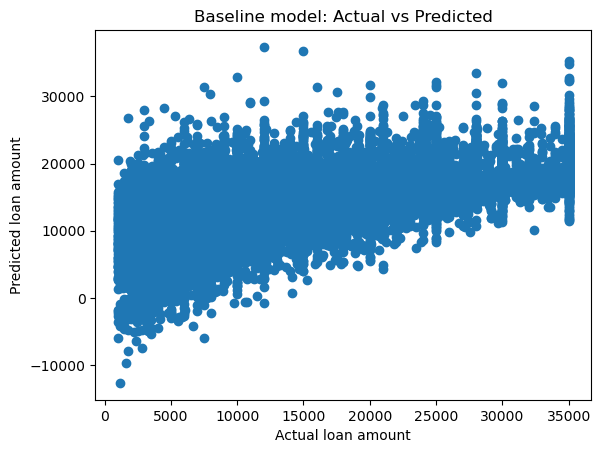

In [22]:
import matplotlib.pyplot as plt

pipe_base_struct.fit(X_train_struct, y_train)
y_pred_base = pipe_base_struct.predict(X_test_struct)

print(r2_score(y_test, y_pred_base))



plt.figure()
plt.scatter(y_test, y_pred_base)
plt.xlabel("Actual loan amount")
plt.ylabel("Predicted loan amount")
plt.title("Baseline model: Actual vs Predicted")

plt.show()


0.3258668423731166


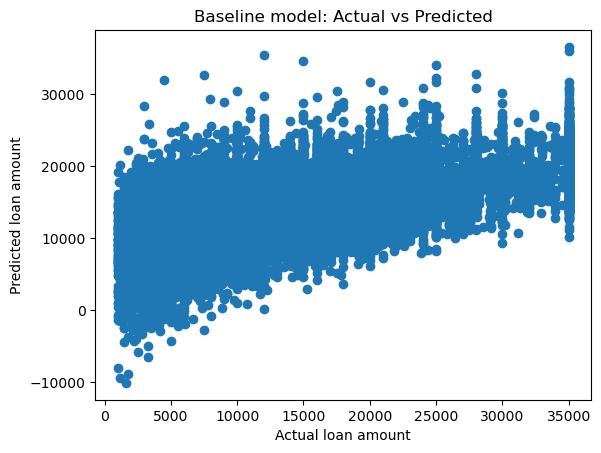

In [34]:
import matplotlib.pyplot as plt

pipe_base_full.fit(X_train_full, y_train)
y_pred_base = pipe_base_full.predict(X_test_full)

print(r2_score(y_test, y_pred_base))



plt.figure()
plt.scatter(y_test, y_pred_base)
plt.xlabel("Actual loan amount")
plt.ylabel("Predicted loan amount")
plt.title("Baseline model: Actual vs Predicted")

plt.show()


# XGBRegressor

0.34082508087158203


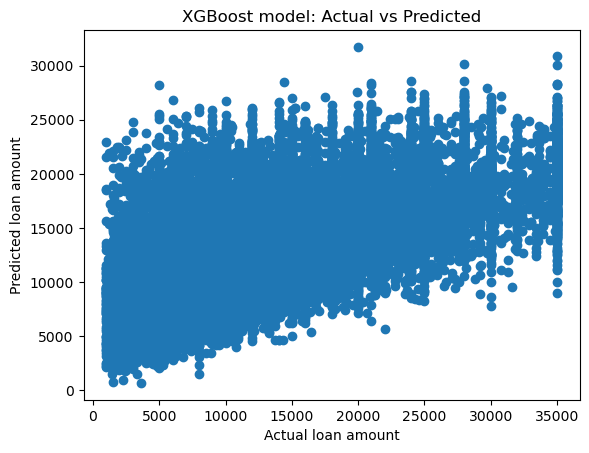

In [35]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

pipe_xgb_struct.fit(X_train_struct, y_train)
y_pred_xgb = pipe_xgb_struct.predict(X_val_struct)

print(r2_score(y_val, y_pred_xgb))

plt.figure()
plt.scatter(y_val, y_pred_xgb)
plt.xlabel("Actual loan amount")
plt.ylabel("Predicted loan amount")
plt.title("XGBoost model: Actual vs Predicted")
plt.show()


Validation R2: 0.36342841386795044


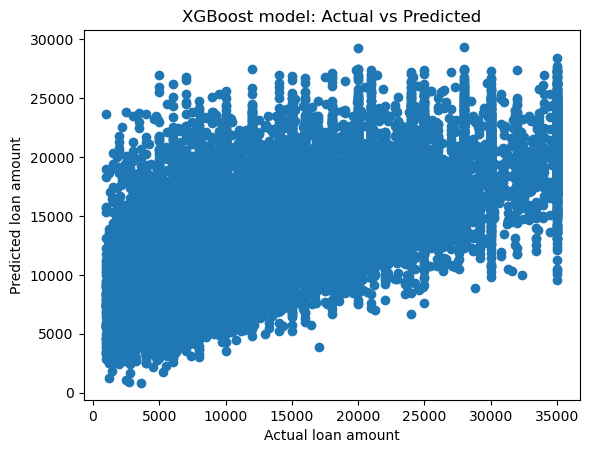

In [23]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

pipe_xgb_full.fit(X_train_full, y_train)
y_pred_xgb = pipe_xgb_full.predict(X_val_full)

print("Validation R2:", r2_score(y_val, y_pred_xgb))

plt.figure()
plt.scatter(y_val, y_pred_xgb)
plt.xlabel("Actual loan amount")
plt.ylabel("Predicted loan amount")
plt.title("XGBoost model: Actual vs Predicted")
plt.show()

# MLP Regressor

c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=90 is greater than n_features=23. All the features will be returned.
  warnings.warn(


0.3400345168001666


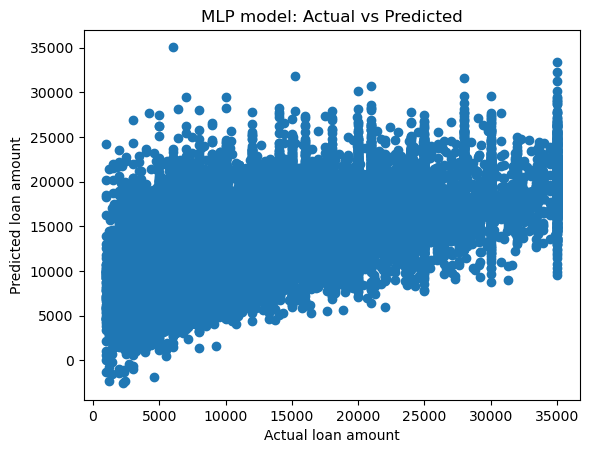

In [37]:
pipe_mlp_struct.fit(X_train_struct, y_train)
y_pred_mlp = pipe_mlp_struct.predict(X_val_struct)

print(r2_score(y_val, y_pred_mlp))

plt.figure()
plt.scatter(y_val, y_pred_mlp)
plt.xlabel("Actual loan amount")  
plt.ylabel("Predicted loan amount")
plt.title("MLP model: Actual vs Predicted")
plt.show()

c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.34748936336021197


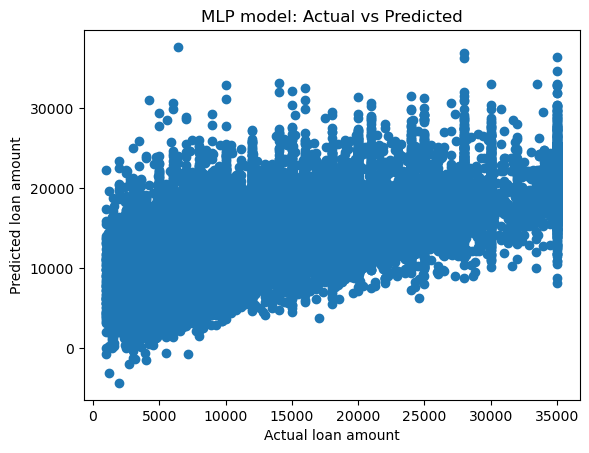

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

pipe_mlp_full.fit(X_train_full, y_train)
y_pred_mlp = pipe_mlp_full.predict(X_val_full)

print(r2_score(y_val, y_pred_mlp))

plt.figure()
plt.scatter(y_val, y_pred_mlp)
plt.xlabel("Actual loan amount")  
plt.ylabel("Predicted loan amount")
plt.title("MLP model: Actual vs Predicted")
plt.show()

# KNeighbors

0.3273503839893087


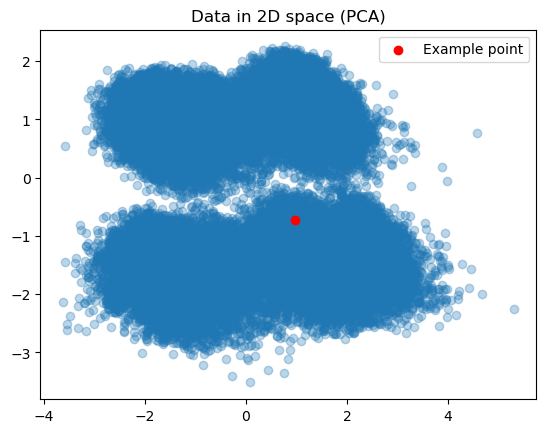

In [38]:
import matplotlib.pyplot as plt
pipe_knn_struct.fit(X_train_struct, y_train)

y_pred_knn = pipe_knn_struct.predict(X_val_struct)

print(r2_score(y_val, y_pred_knn))


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_struct)
X_val_scaled = scaler.transform(X_val_struct)

# PCA naar 2D
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_val_2d = pca.transform(X_val_scaled)

# plot alles
plt.figure()
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], alpha=0.3)

# highlight 1 punt
plt.scatter(X_val_2d[0,0], X_val_2d[0,1], color='red', label='Example point')

plt.legend()
plt.title("Data in 2D space (PCA)")
plt.show()

0.2679882420140226


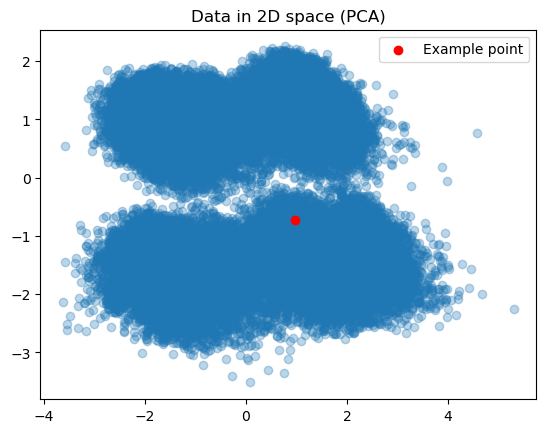

In [39]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
pipe_knn_full.fit(X_train_full, y_train)

y_pred_knn = pipe_knn_full.predict(X_val_full)

print(r2_score(y_val, y_pred_knn))


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# schaal data (los, niet via pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_struct)
X_val_scaled = scaler.transform(X_val_struct)

# PCA naar 2D
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_val_2d = pca.transform(X_val_scaled)

# plot alles
plt.figure()
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], alpha=0.3)

# highlight 1 punt
plt.scatter(X_val_2d[0,0], X_val_2d[0,1], color='red', label='Example point')

plt.legend()
plt.title("Data in 2D space (PCA)")
plt.show()

# Model evaluation

In [10]:
import numpy as np
import pandas as pd

from pluggy import Result
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.feature_selection import GenericUnivariateSelect, r_regression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


# Combine train and validation
X_trainval_struct = np.vstack([X_train_struct, X_val_struct])
X_trainval_full = np.vstack([X_train_full, X_val_full])
y_trainval = np.concatenate([y_train, y_val])

# Evaluation function
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    return {
        "model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

results = []

# Structured models
results.append(evaluate_model("XGB_struct", pipe_xgb_struct, X_trainval_struct, y_trainval, X_test_struct, y_test))
results.append(evaluate_model("MLP_struct", pipe_mlp_struct, X_trainval_struct, y_trainval, X_test_struct, y_test))
results.append(evaluate_model("KNN_struct", pipe_knn_struct, X_trainval_struct, y_trainval, X_test_struct, y_test))

# Full models
results.append(evaluate_model("XGB_full", pipe_xgb_full, X_trainval_full, y_trainval, X_test_full, y_test))
results.append(evaluate_model("MLP_full", pipe_mlp_full, X_trainval_full, y_trainval, X_test_full, y_test))
results.append(evaluate_model("KNN_full", pipe_knn_full, X_trainval_full, y_trainval, X_test_full, y_test))

# Result table
df_results = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

df_results["R2"] = df_results["R2"].round(4)
df_results["RMSE"] = df_results["RMSE"].round(2)
df_results["MAE"] = df_results["MAE"].round(2)
df_results["MAPE (%)"] = df_results["MAPE (%)"].round(2)

print(df_results)

c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=90 is greater than n_features=22. All the features will be returned.
  warnings.warn(
c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


        model      R2     RMSE      MAE  MAPE (%)
0    XGB_full  0.3703  6363.26  5008.09     56.81
1    MLP_full  0.3444  6492.94  5089.68     58.22
2  XGB_struct  0.3436  6496.78  5113.66     58.34
3  MLP_struct  0.3407  6510.76  5120.81     58.33
4  KNN_struct  0.3310  6558.50  5165.42     59.47
5    KNN_full  0.2727  6838.41  5445.45     64.71


Test R2: 0.3702792525291443


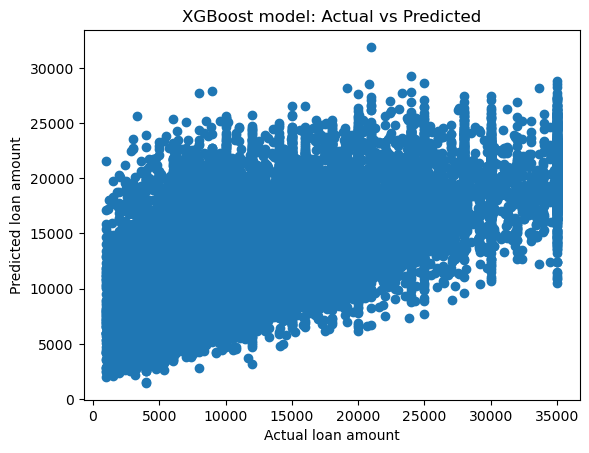

In [27]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# final model fitten op train + validation
pipe_xgb_full.fit(X_trainval_full, y_trainval)

# voorspellen op test set
y_pred_xgb = pipe_xgb_full.predict(X_test_full)

# score checken
print("Test R2:", r2_score(y_test, y_pred_xgb))

# plot actual vs predicted
plt.figure()
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual loan amount")
plt.ylabel("Predicted loan amount")
plt.title("XGBoost model: Actual vs Predicted")

plt.show()

# T-test

In [13]:
from sklearn.metrics import r2_score
from tqdm import tqdm
import numpy as np

model1_scores = []
model2_scores = []

n_boot = 2000
n_test = len(y_test)

for i in tqdm(range(n_boot)):
    # bootstrap sample van de test set
    idx = np.random.choice(np.arange(n_test), size=n_test, replace=True)

    X_struct_sample = X_test_struct[idx]
    X_full_sample = X_test_full[idx]
    y_sample = y_test[idx]

    # XGB structured
    y_pred_struct = pipe_xgb_struct.predict(X_struct_sample)
    score1 = r2_score(y_sample, y_pred_struct)
    model1_scores.append(score1)

    # XGB full
    y_pred_full = pipe_xgb_full.predict(X_full_sample)
    score2 = r2_score(y_sample, y_pred_full)
    model2_scores.append(score2)

100%|██████████| 2000/2000 [07:17<00:00,  4.57it/s]


C:\Users\thomd\AppData\Local\Temp\ipykernel_6484\2868183038.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


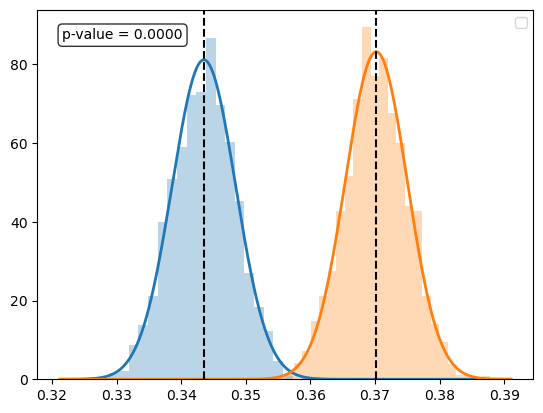

p-value: 0.0


In [19]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Fit a normal distribution to the data
mu1, std1 = norm.fit(model1_scores)
mu2, std2 = norm.fit(model2_scores)

# Plot the histogram
plt.hist(model1_scores, bins=25, density=True, alpha=0.3, color=colors[0])
plt.hist(model2_scores, bins=25, density=True, alpha=0.3, color=colors[1])

# Plot the probability distribution function
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 1000)
p1 = norm.pdf(x, mu1, std1)
p2 = norm.pdf(x, mu2, std2)
plt.plot(x, p1, colors[0], linewidth=2)
plt.plot(x, p2, colors[1], linewidth=2)

# Plot the mean value
plt.axvline(x=mu1, linestyle="--", color="black")
plt.axvline(x=mu2, linestyle="--", color="black")
# ax = plt.gca()

# Calculate p-value
statistic, pvalue = stats.ttest_ind(model1_scores, model2_scores)

# Add p-value to the plot
plt.text(
    0.05, 0.95,
    f"p-value = {pvalue:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.show()

print("p-value:", pvalue)

In [18]:
from scipy.stats import ttest_rel

def get_predictions(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    return model.predict(X_test)

preds = {}

preds["XGB_struct"] = get_predictions(pipe_xgb_struct, X_trainval_struct, y_trainval, X_test_struct)
preds["XGB_full"]   = get_predictions(pipe_xgb_full,   X_trainval_full,   y_trainval, X_test_full)

preds["MLP_struct"] = get_predictions(pipe_mlp_struct, X_trainval_struct, y_trainval, X_test_struct)
preds["MLP_full"]   = get_predictions(pipe_mlp_full,   X_trainval_full,   y_trainval, X_test_full)

preds["KNN_struct"] = get_predictions(pipe_knn_struct, X_trainval_struct, y_trainval, X_test_struct)
preds["KNN_full"]   = get_predictions(pipe_knn_full,   X_trainval_full,   y_trainval, X_test_full)


# t-test funtion
def run_ttest(y_true, pred_struct, pred_full, model_name):
    error_struct = np.abs(y_true - pred_struct)
    error_full = np.abs(y_true - pred_full)

    t_stat, p_value = ttest_rel(error_struct, error_full)

    return {
        "model": model_name,
        "mean_error_struct": np.mean(error_struct),
        "mean_error_full": np.mean(error_full),
        "t_stat": t_stat,
        "p_value": p_value
    }


# run tests
ttest_results = []

ttest_results.append(run_ttest(y_test, preds["XGB_struct"], preds["XGB_full"], "XGB"))
ttest_results.append(run_ttest(y_test, preds["MLP_struct"], preds["MLP_full"], "MLP"))
ttest_results.append(run_ttest(y_test, preds["KNN_struct"], preds["KNN_full"], "KNN"))

df_ttest = pd.DataFrame(ttest_results)

df_ttest["p_value"] = df_ttest["p_value"].round(5)
df_ttest["mean_error_struct"] = df_ttest["mean_error_struct"].round(2)
df_ttest["mean_error_full"] = df_ttest["mean_error_full"].round(2)

print(df_ttest)

c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=90 is greater than n_features=22. All the features will be returned.
  warnings.warn(
c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\thomd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  model  mean_error_struct  mean_error_full     t_stat  p_value
0   XGB            5113.66          5008.09  12.892999  0.00000
1   MLP            5120.81          5089.68   2.221613  0.02632
2   KNN            5165.42          5445.45 -20.587299  0.00000


# SHAP Analyses

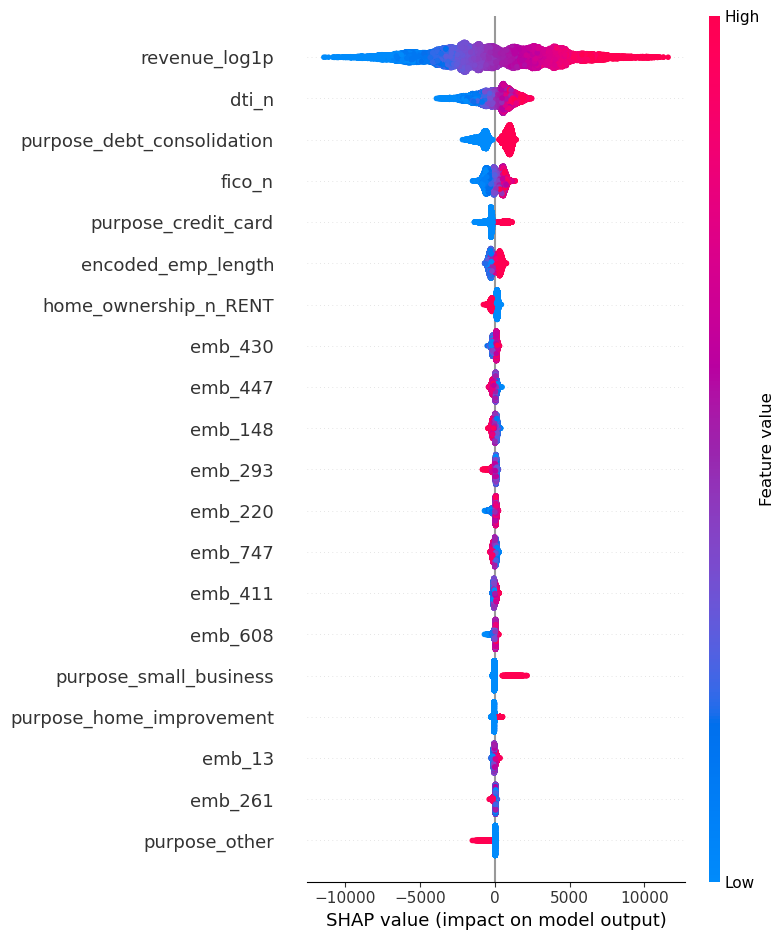

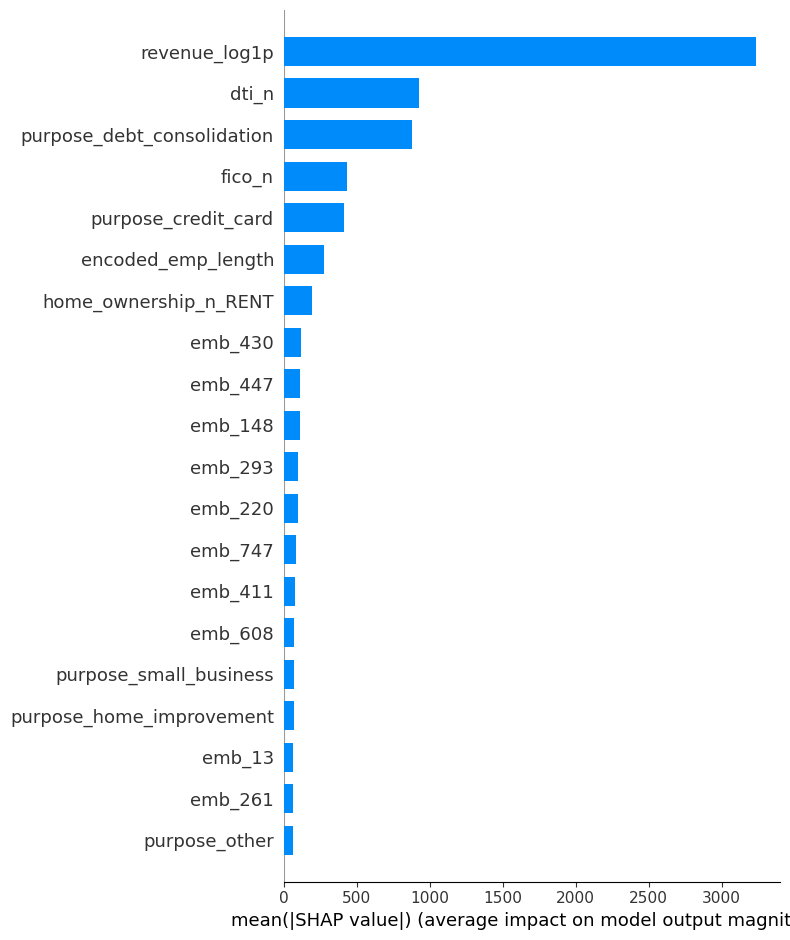

                       feature  mean_abs_shap
0                revenue_log1p    3237.098633
1                        dti_n     925.566772
2   purpose_debt_consolidation     880.458252
3                       fico_n     432.009308
4          purpose_credit_card     411.566193
5           encoded_emp_length     273.775543
6        home_ownership_n_RENT     190.950562
7                      emb_430     116.576775
8                      emb_447     114.409569
9                      emb_148     113.573570
10                     emb_293      99.237129
11                     emb_220      96.071236
12                     emb_747      83.882462
13                     emb_411      74.132767
14                     emb_608      70.499519
15      purpose_small_business      70.436951
16    purpose_home_improvement      69.391281
17                      emb_13      66.251198
18                     emb_261      65.075813
19               purpose_other      62.652725


In [56]:
import pandas as pd
import shap
import numpy as np

structured_feature_names = df_all.drop(columns=columns_drop).columns.tolist()

n_total_features = X_test_full.shape[1]
n_struct = len(structured_feature_names)

embedding_feature_names = [f"emb_{i}" for i in range(n_total_features - n_struct)]


full_feature_names = structured_feature_names + embedding_feature_names

X_test_full_named = pd.DataFrame(X_test_full, columns=full_feature_names)

xgb_model = pipe_xgb_full.named_steps["xgbregressor"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_full_named)

shap.summary_plot(shap_values, X_test_full_named)
shap.summary_plot(shap_values, X_test_full_named, plot_type="bar")

mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_shap = pd.DataFrame({
    "feature": X_test_full_named.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(df_shap.head(20))

# SHAP on text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

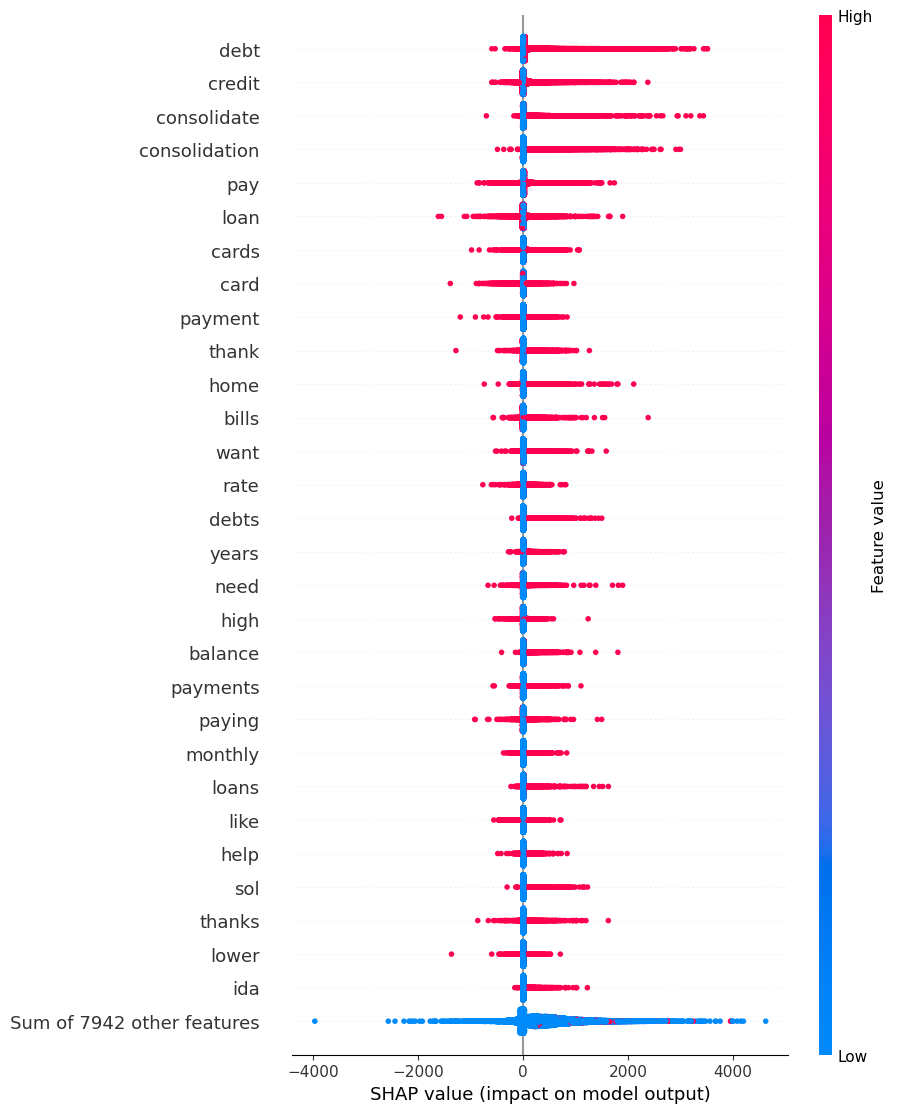

In [20]:
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from transformers import AutoTokenizer, AutoModel


desc_col = "desc"
max_texts = 15000
max_length = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()
stopwords = set(ENGLISH_STOP_WORDS)


# BERT embedding function
def get_embeddings(texts):
    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()


# Getting test texts and structured data
test_original_indices = X_test.index
texts_test = df_all.loc[test_original_indices, desc_col].fillna("").astype(str).reset_index(drop=True)
texts_sample = texts_test.iloc[:max_texts].reset_index(drop=True)
X_struct_sample = X_test_struct[:max_texts]


# SHAP per tekst
all_word_shap = []
for i in range(len(texts_sample)):
    fixed_struct = X_struct_sample[i].reshape(1, -1)
    def predict_from_text(texts):
        emb = get_embeddings(texts)
        struct_repeated = np.repeat(
            fixed_struct,
            repeats=len(texts),
            axis=0
        )
        X_full_text = np.hstack([struct_repeated, emb])
        return pipe_xgb_full.predict(X_full_text)

    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_from_text, masker)

    shap_value = explainer([texts_sample.iloc[i]])
    all_word_shap.append(shap_value[0])

# Word matrix
word_scores = defaultdict(lambda: np.zeros(len(all_word_shap)))

for i, sv in enumerate(all_word_shap):
    tokens = sv.data
    values = sv.values
    for token, val in zip(tokens, values):
        word = str(token).lower().strip().replace("##", "")
        if (
            word not in stopwords and
            len(word) > 2 and
            word.isalpha()
        ):
            word_scores[word][i] += val



# Dataframe creation
words = list(word_scores.keys())

X_word_shap = np.column_stack([word_scores[w] for w in words])
word_names = np.array(words)
mean_abs = np.abs(X_word_shap).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
X_word_shap = X_word_shap[:, order]
word_names = word_names[order]


# SHAP Explanation object
word_explanation = shap.Explanation(
    values=X_word_shap,
    data=(X_word_shap != 0).astype(int),
    feature_names=word_names
)


# Beeswarm plot
shap.plots.beeswarm(
    word_explanation,
    max_display=30
)

plt.show()

# SHAP on BERT

In [22]:
import numpy as np
import pandas as pd

# error prediction
y_pred = pipe_xgb_full.predict(X_test_full)
errors = np.abs(y_test - y_pred)

# deciding indencies
idx_best = np.argmin(errors)
idx_worst = np.argmax(errors)
median_error = np.median(errors)
idx_avg = np.argmin(np.abs(errors - median_error))

#creating table
results = pd.DataFrame({
    "type": ["best", "worst", "average"],
    "idx": [idx_best, idx_worst, idx_avg],
    "actual_loan": [
        y_test[idx_best],
        y_test[idx_worst],
        y_test[idx_avg]
    ],
    "predicted_loan": [
        y_pred[idx_best],
        y_pred[idx_worst],
        y_pred[idx_avg]
    ],
    "error": [
        errors[idx_best],
        errors[idx_worst],
        errors[idx_avg]
    ]
})

print(results)

# saving indencies
idx_best_case = idx_best
idx_worst_case = idx_worst
idx_avg_case = idx_avg

      type    idx  actual_loan  predicted_loan         error
0     best  22546        12800    12799.781250      0.218750
1    worst  22532        35000     9620.527344  25379.472656
2  average    962        14400    18511.148438   4111.148438


In [23]:
import numpy as np
import torch
import shap
from transformers import AutoTokenizer, AutoModel

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()
fitted_model = pipe_xgb_full

# Function: text -> BERT embeddings
def get_embeddings(texts):
    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)

    return outputs.last_hidden_state[:, 0, :].cpu().numpy()

# Cases to explain
cases = {
    "Best prediction": idx_best_case,
    "Worst prediction": idx_worst_case,
    "Average prediction": idx_avg_case
}

masker = shap.maskers.Text(tokenizer)

shap_results = {}

# Compute SHAP values for all cases
for case_name, idx in cases.items():

    original_idx = X_test.index[idx]
    text = df_all.loc[original_idx, "desc"]

    structured_row = X_test.iloc[[idx]].values[:, :24]

    def f(texts, structured_row=structured_row):
        emb = get_embeddings(texts)

        struct_rep = np.repeat(
            structured_row,
            repeats=len(texts),
            axis=0
        )

        X_full = np.hstack([struct_rep, emb])

        return fitted_model.predict(X_full)

    explainer = shap.Explainer(f, masker)
    shap_values = explainer([text])

    shap_results[case_name] = {
        "idx": idx,
        "text": text,
        "shap_values": shap_values
    }

    print(f"{case_name} | index: {idx}")
    print(text[:250])
    print("-" * 80)

# Plot all three native SHAP text plots
for case_name, result in shap_results.items():
    print(case_name)
    shap.plots.text(result["shap_values"][0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best prediction | index: 22546
Excellent investment! I am moving to a new job and need a loan to cover moving costs (some of which will be reimbursed) and to consolidate another loan. I'm financially savvy with a clear budget and definitive repayment plan, making this a superb inv
--------------------------------------------------------------------------------
Worst prediction | index: 22532
Family medical emergency.
--------------------------------------------------------------------------------
Average prediction | index: 962
- I wish to consolidte my debt and pay off my credit cards. - I work at a stable company that continue to grow in the slow economy - I have excellent credit.
--------------------------------------------------------------------------------
Best prediction


Worst prediction


Average prediction


In [61]:
import numpy as np
import html
from IPython.display import display, HTML

def make_shap_html(case_name, shap_values):
    sv = shap_values[0]

    tokens = np.array(sv.data)
    values = np.array(sv.values).astype(float)

    base_value = float(np.array(sv.base_values).ravel()[0])
    prediction = base_value + values.sum()

    max_abs = np.max(np.abs(values))
    if max_abs == 0:
        max_abs = 1

    token_html = ""

    for token, value in zip(tokens, values):
        token_clean = html.escape(str(token))
        intensity = min(abs(value) / max_abs, 1)

        if value >= 0:
            bg = f"rgba(255, 0, 90, {0.25 + 0.75 * intensity})"
            border = "rgb(255, 0, 90)"
        else:
            bg = f"rgba(0, 110, 255, {0.25 + 0.75 * intensity})"
            border = "rgb(0, 110, 255)"

        token_html += f"""
        <span style="
            background:{bg};
            border-bottom:3px solid {border};
            color:white;
            padding:4px 6px;
            margin:2px;
            border-radius:3px;
            display:inline-block;
            font-size:15px;
            font-weight:500;">
            {token_clean}
        </span>
        """

    return f"""
    <div style="
        background:white;
        color:black;
        padding:20px;
        margin-bottom:25px;
        font-family:Arial, sans-serif;
        max-width:1100px;
        border:1px solid #ddd;
        border-radius:4px;">

        <h3 style="margin-top:0;">{html.escape(case_name)}</h3>

        <div style="
            display:flex;
            justify-content:center;
            gap:100px;
            margin-bottom:15px;
            font-size:13px;">
            <div>
                <div style="color:#777;">base value</div>
                <b>{base_value:.2f}</b>
            </div>
            <div>
                <div style="color:#777;">f(inputs)</div>
                <b>{prediction:.2f}</b>
            </div>
        </div>

        <div style="border-top:2px solid #aaa; margin-bottom:15px;"></div>

        <div style="line-height:2.4; text-align:left;">
            {token_html}
        </div>
    </div>
    """

all_html = ""

for case_name, result in shap_results.items():
    all_html += make_shap_html(
        case_name,
        result["shap_values"]
    )

display(HTML(all_html))